**Fundamentals of Machine Learning - Exercise 2** 💪
---

---
### 🎯 Aim of the Exercise

In this exercise, you will learn how to perform **Exploratory Data Analysis (EDA)** by:

- 🏷️ understanding **variable types** and working with data types,
- ❓ identifying **missing values and potential outliers**,
- 📏 calculating and interpreting **descriptive statistics**,
- 📊 using visualizations to explore **distributions, relationships, and patterns** in the data.

### Import libraries 📘

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import data 🚢

In [2]:
df= sns.load_dataset("titanic")

<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'> Let's Explore the Data! 🔍 </font></h2>
</div>

Exploratory Data Analysis (EDA) starts with understanding our data.  
Let's begin with a quick inspection of the dataset.

🧩 Let's display the first few rows of the dataset.

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


❓What does one row represent?  
❓Which column could be our target?

🧩 Let's check the basic information about the DataFrame

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


❓ How many rows and columns are there?   
❓ Which columns contain missing values?  
❓ Which numerical dtypes might statistically represent categories?  
❓ Does a Pandas dtype tell us how data are stored, what they mean, or both?

<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'> Understanding Variable Types 🏷️  </font></h2>
</div>  

#### Example 1: The `age` Variable

In [6]:
df["age"].head(10)

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5     NaN
6    54.0
7     2.0
8    27.0
9    14.0
Name: age, dtype: float64

🧩 Inspect the values and the dtype of `age`. Try to explain why Pandas stores it as `float64`, determine its statistical variable type, and identify one potential data-quality issue that should be examined before analysis.

#### Example 2: The `survived` Variable

In [7]:
df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

🧩 survived is stored as `int64`. What do its values represent, how should the variable be classified statistically, and when can its numerical encoding be useful?

#### Example 3: Comparing `pclass` and `fare`

In [8]:
df[["pclass","fare"]].head()

,pclass,fare
0,3,7.2500
1,1,71.2833
2,3,7.9250
3,1,53.1000
4,3,8.0500


🧩 Both variables contain numbers. Explain how their statistical meanings differ and which summaries would you choose for each variable, and why?

#### 🧩Task 1  
Classify each variable by its statistical meaning. Be ready to justify your answer.  

| Variable      | Pandas dtype | Statistical type |
| ------------- | ------------ | ---------------- |
| `fare`        | `float64`    | Spojitá          |
| `embark_town` | `str`        | Nominální         |
| `alone`       | `bool`       |Binární       |
| `sibsp`       | `int64`      |Diskrétní |


❓ Why do variable types matter for EDA?

💡 A Pandas "dtype" tells us how the data are stored, not necessarily what the variable represents statistically.  

💡 A quick inspection is an important first step in EDA. It helps us understand what our dataset looks like before we analyze it in more detail.

<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'> Converting Data Types 🔄  </font></h2>
</div>

- Once we understand what the variables represent, we can convert selected columns to more appropriate data types.

string → category

`sex` was stored as a string. Statistically, it represents a nominal categorical variable. We use .astype("category") to make this intended meaning explicit in Pandas.

In [9]:
print("Before:", df["sex"].dtype)

df["sex"] = df["sex"].astype("category")

print("After:", df["sex"].dtype)

Before: str
After: category


💡 .astype() can be used to convert a column to another data type. To save the conversion, assign the result back to the column.

🧩 Convert `pclass` to the Pandas category dtype and verify the result.

In [10]:
print("Before:", df["pclass"].dtype)

df["pclass"] = df["pclass"].astype("category")

print("After:", df["pclass"].dtype)

Before: int64
After: category


❓Did this conversion change the meaning or values of pclass?

❓Do all statistically categorical variables have to use the Pandas category dtype?   
❓ survived is also a categorical variable. Why might we keep it as an integer (0 and 1) instead of converting it to category?"

<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'> Redundant variables 🔁</font></h2>
</div>

Different columns may sometimes represent the same underlying information. During EDA, we should identify such variables before using them in a model.

Inspect all column names:

In [11]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

🧩 Based on the column names, which variables might contain duplicate information?

In [12]:
df[["survived", "alive",
    "pclass", "class",
    "embarked", "embark_town"]].head()

,survived,alive,pclass,class,embarked,embark_town
0,0,no,3,Third,S,Southampton
1,1,yes,1,First,C,Cherbourg
2,1,yes,3,Third,S,Southampton
3,1,yes,1,First,S,Southampton
4,0,no,3,Third,S,Southampton


A few displayed rows are not sufficient to prove that two columns contain the same information. We should check all observations.

In [14]:
display(df[["survived", "alive"]].drop_duplicates())
display(df[["pclass", "class"]].drop_duplicates())
display(df[["embarked", "embark_town"]].drop_duplicates())

,survived,alive
0,0,no
1,1,yes


,pclass,class
0,3,Third
1,1,First
9,2,Second


,embarked,embark_town
0,S,Southampton
1,C,Cherbourg
5,Q,Queenstown
61,NaN,NaN


💡 .drop_duplicates()  returns all unique combinations of their values. 

❓ Based on these results, would you keep both columns from each pair for modelling? Why or why not?   
❓ If survived is our prediction target, which column must not be used as an input feature, and why?

<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'> Missing values❓</font></h2>
</div>

- Real-world datasets often contain missing values.  
- Missing values may affect summary statistics, visualisations, and machine-learning models.  
- Before choosing a treatment, we should determine where values are missing and how much data is affected.

🧩 During the initial inspection, we noticed that some columns contain missing values. Let's examine them more closely:

In [15]:
missing_summary = pd.DataFrame({
    "Missing count": df.isna().sum(),
    "Missing percentage": (df.isna().mean() * 100).round(1)
})

missing_summary[missing_summary["Missing count"] > 0]

,Missing count,Missing percentage
age,177,19.9
embarked,2,0.2
deck,688,77.2
embark_town,2,0.2


❓ Would you handle the missing values in `embark_town`, `age`, and `deck` in the same way? Why or why not?

#### 🛠️ <font color='#05c3de'> Handling Missing Values </font>  

There are several ways to handle missing values. Let's look at some common options:

 **1. Remove a variable**  

 A variable may be removed when it contains extensive missing data and its remaining information is not sufficiently useful for the intended analysis.

In [16]:
df_without_deck = df.drop(columns=["deck"])
print("Original number of columns:", df.shape[1])
print("Number of columns after removal:", df_without_deck.shape[1])
print("Is deck still present?", "deck" in df_without_deck.columns)

Original number of columns: 15
Number of columns after removal: 14
Is deck still present? False


❓ Would you remove `deck` based only on the percentage of missing values?  
❓What else should be considered before removing a variable?

**2a. Removing all incomplete rows**

🧩 If we remove every row containing at least one missing value, approximately how much data do you think will remain?  

A. More than 80%  
B. Approximately half  
C. Less than 25%

In [17]:
print("Original:", df.shape)
print("After dropna():", df.dropna().shape)

Original: (891, 15)
After dropna(): (182, 15)


❓ Would  df.dropna() be a reasonable default strategy for this dataset? Why or why not?  
❓ Apart from reducing the sample size, how could removing incomplete observations bias the analysis?

💡 dropna() removes rows containing at least one missing value.  

**2b. Removing observations based on one selected variable**

In [18]:
df_known_age = df.dropna(subset=["age"])

print("Original number of observations:", len(df))
print("Observations with known age:", len(df_known_age))
print("Observations removed:", len(df) - len(df_known_age))

Original number of observations: 891
Observations with known age: 714
Observations removed: 177


❓ When might removing observations with missing age be acceptable?  
❓ What information could be lost by removing all passengers whose age is unknown?

**3. Replace missing values**  

 Missing values can also be replaced with an estimated value. This is called **imputation**. 


The following example replaces missing ages with the median age:

In [19]:
age_filled = df["age"].fillna(df["age"].median())

print("Median age:", df["age"].median())
print("Missing before:", df["age"].isna().sum())
print("Missing after:", age_filled.isna().sum())

Median age: 28.0
Missing before: 177
Missing after: 0


❓ What are the possible disadvantages of replacing all missing ages with the median?

Other possible decisions include:

- removing a variable with extensive missingness,
- removing rows missing a specific essential value,
- using a more informed imputation method,
- adding an indicator showing whether the value was missing.

🧩 Individual task

Consider `embark_town`, `age`, and `deck`. Would you apply the same missing-value strategy to all three variables? Propose one possible decision for each variable and justify it.

| Variable      | Missing percentage | Possible decision | Reason |
| ------------- | -----------------: | ----------------- | ------ |
| `embark_town` |               0.2% | delete the rows| very little amount of missed data |
| `age`         |              19.9% | fill with median| not too much, we can fill it|
| `deck`        |              77.2% | delete the columns| too much missed data |


💡 There is no universally correct missing-value strategy. The decision depends on:

- the amount of missing data,  
- the meaning of the variable,  
- why values may be missing,  
- the intended analysis or model,  
- the possible effect of removing or replacing values.

#### Cheat Sheet

| Approach             | Example                     | What does it do?                    |
| -------------------- | --------------------------- | ----------------------------------- |
| Remove a column      | `df.drop(columns=["deck"])` | Removes the entire variable         |
| Remove rows          | `df.dropna()`               | Removes rows with any missing value |
| Remove selected rows | `df.dropna(subset=["age"])` | Removes rows where `age` is missing |
| Replace values       | `df["age"].fillna(...)`     | Replaces missing values             |


<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'> From Questions to Visualisations 📊 </font></h2> 
</div> 

- Visualisations help us explore distributions, identify unusual observations, and investigate relationships that may not be obvious from numerical summaries alone.  
- Before creating a graph, we should define the analytical question and identify the types of variables involved.  
=> These decisions help us choose an appropriate visualisation.

🧩 Question: How are passenger ages distributed?  
What type of variable is `age`, and which visualisation would be appropriate for examining its distribution?


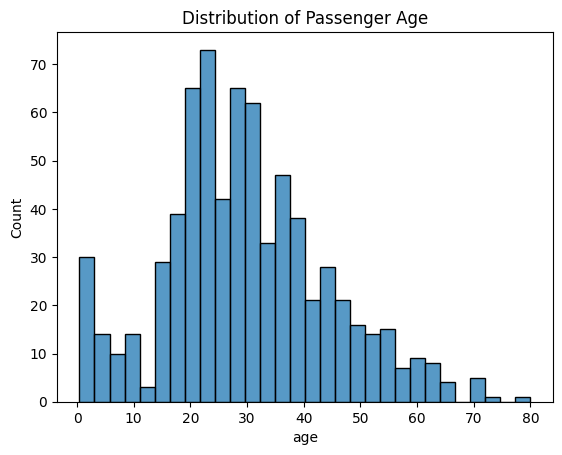

In [20]:
sns.histplot(data=df, x="age", bins=30)
plt.title("Distribution of Passenger Age")
plt.show()

❓ Where are most passenger ages concentrated?  
❓ Is it approximately symmetric or skewed?  
❓ Are there any features that deserve further investigation?

💡 A histogram is suitable for exploring the distribution of one numerical variable. Numerical values are grouped into intervals called bins.

🧩 Task — Explore the distribution of `fare`  
- Identify the statistical type of `fare`.  
- Select an appropriate visualisation of its distribution.  
- Add an informative title and axis label.  
- Describe the shape of the distribution in one sentence.

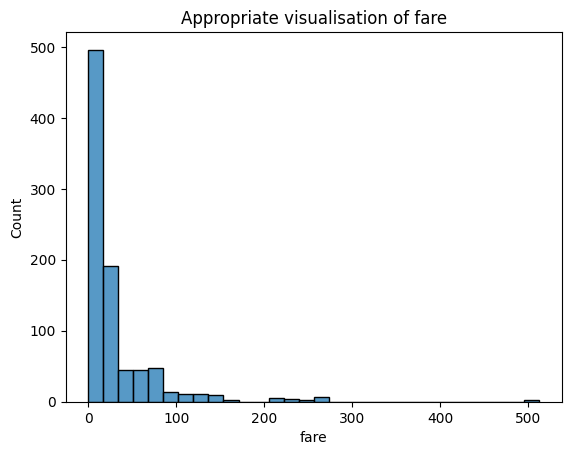

In [21]:
# Create an appropriate visualisation of fare
sns.histplot(data=df, x="fare", bins=30)
plt.title("Appropriate visualisation of fare")
plt.show()

❓ Is the distribution approximately symmetric, left-skewed, or right-skewed?  
❓ What does the long right tail represent?  
❓ Based on the histogram, which do you expect to be larger: the mean or the median fare? Why?

In [22]:
print("Mean fare:", df['fare'].mean())
print("Median fare:", df['fare'].median())

Mean fare: 32.204207968574636
Median fare: 14.4542


A histogram shows the shape of the distribution. Now we want a compact summary of its median, quartiles, spread, and potential outliers.

### Exploring Potential Outliers with a Boxplot  

A boxplot provides a compact summary of a numerical distribution:

- the line inside the box represents the median,  
- the edges of the box represent Q1 and Q3,  
- the box contains the middle 50% of observations,  
- the interquartile range is \(IQR = Q3-Q1\),  
- points beyond the whiskers are displayed as potential outliers.

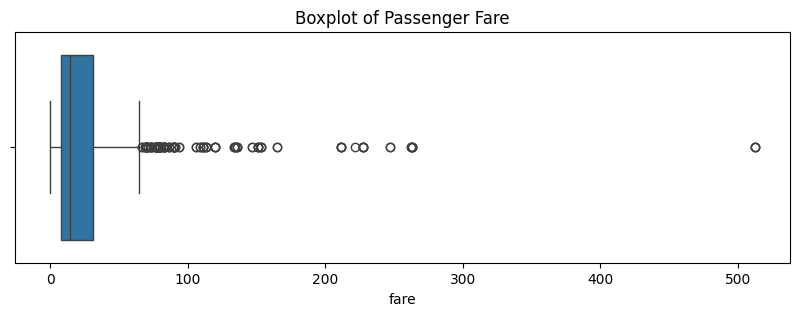

In [23]:
plt.figure(figsize=(10, 3))
sns.boxplot(data=df, x="fare")
plt.title("Boxplot of Passenger Fare")
plt.show()

❓ Where is the median approximately located?  
❓ How does the boxplot support the right-skewed shape observed in the histogram?

#### IQR rule, Let´s breake it down

In [24]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

potential_outliers = df[
    (df["fare"] < lower_fence) |
    (df["fare"] > upper_fence)
]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower fence: {lower_fence:.2f}")
print(f"Upper fence: {upper_fence:.2f}")
print("Number of potential outliers:", len(potential_outliers))

Q1: 7.91
Q3: 31.00
IQR: 23.09
Lower fence: -26.72
Upper fence: 65.63
Number of potential outliers: 116


💡 Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are commonly identified as potential outliers.

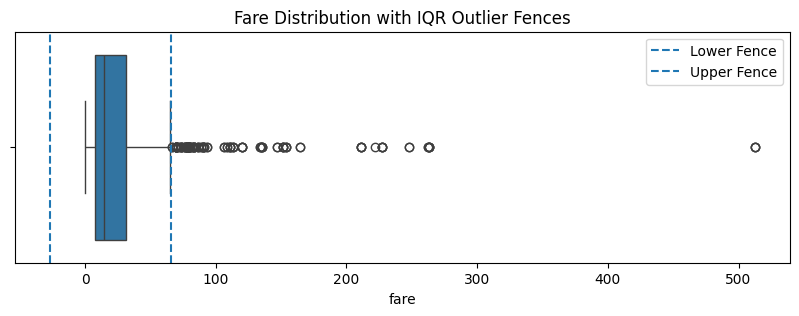

In [25]:
plt.figure(figsize=(10, 3))

sns.boxplot(data=df, x="fare")

plt.axvline(lower_fence, linestyle="--", label="Lower Fence")
plt.axvline(upper_fence, linestyle="--", label="Upper Fence")

plt.title("Fare Distribution with IQR Outlier Fences")
plt.legend()
plt.show()

❓ The IQR rule identifies 116 potential outliers. Does this mean that 116 fares are incorrect?

🧩 A value may appear unusual in the complete dataset but be more understandable within a relevant subgroup.   
Let´s compare fare distributions across passenger classes.

C:\Users\Diana\AppData\Local\Temp\ipykernel_11052\1162911855.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="fare", y="class", palette="Set2", legend=False)


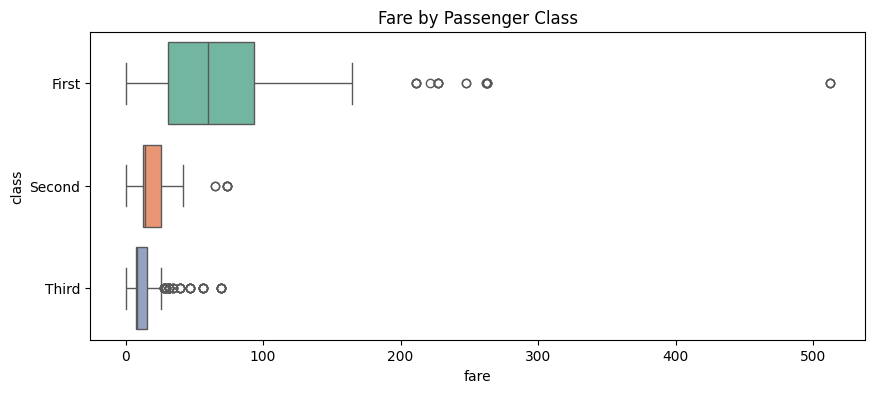

In [26]:
plt.figure(figsize=(10, 4))

sns.boxplot(data=df, x="fare", y="class", palette="Set2", legend=False)
plt.title("Fare by Passenger Class")
plt.show()


❓ Which `class` has the highest median `fare`?  
❓ Do the `fare` distributions differ substantially across classes?  
❓ Are all high fares explained by passenger class?

💡 Potential outliers should not be removed automatically.   
Before deciding what to do with them, we should investigate whether they are errors or valid observations and consider the context in which they occur.

<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'>Descriptive Statistics </font></h2>
</div>

Visualisations and descriptive statistics provide complementary information. A graph shows the shape of a distribution, while numerical summaries describe its centre, spread, and range.

🧩 Task — Generate descriptive statistics for `age` and `fare`.

In [27]:
df[["age", "fare"]].describe()

,age,fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


❓ Compare the centre, spread, and observed range of `age` and `fare`. Which values suggest that fare is strongly right-skewed?  
❓ Can describe() show the complete shape of a distribution? What information might still be missing?

 `describe()` provides several useful summary statistics:

- `count` – number of non-missing observations
- `mean` – average value
- `std` – standard deviation
- `min` and `max` – range of observed values
- `25%`, `50%`, `75%` – quartiles (`50%` is the median)

💡 The standard deviation (std) describes how spread out the values are around the mean. A larger standard deviation indicates greater variability.

 ###  Describing a Binary variable

In [28]:
df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

❓ What do these counts tell us?  

In [29]:
df["survived"].mean()

np.float64(0.3838383838383838)

❓ What does the mean of a binary variable encoded as 0 and 1 represent?

    
    
💡 Descriptive statistics should be interpreted together with visualisations. For skewed distributions, the median and IQR are often more representative than the mean and standard deviation. A numerical summary alone does not show the complete shape of a distribution.

💡 When a binary variable is encoded as 0 and 1, its mean represents the proportion of observations encoded as 1.

<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'>Exploring Relationships 🔗</font></h2>
</div>

- So far, we have explored individual variables.

- We will now investigate whether variables are associated with each other.

#### 1. Sex and Survival

🧩 **Analytical question:** Is passenger sex associated with observed survival?  

❓ What are the statistical types of sex and survived?  

- Begin with counts

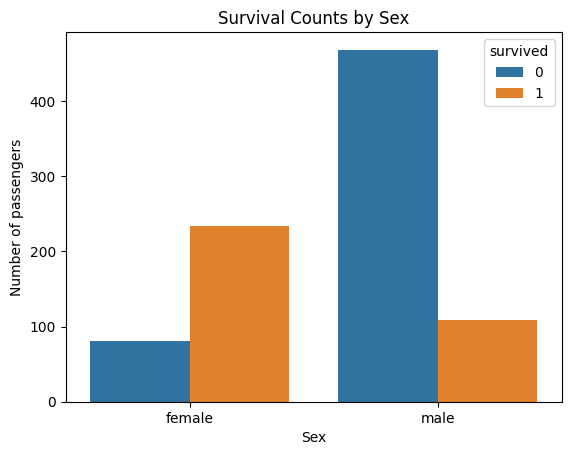

In [30]:
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Survival Counts by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of passengers")
plt.show()

❓ How does survival appear to differ between male and female passengers?  
❓ Does this countplot directly compare the probability of survival within each group?

🧩 Task — Compare survival rates  
Calculate the observed survival rate separately for female and male passengers.  
Store the result in a variable called survival_by_sex and display it.

In [38]:
survival_by_sex = df.groupby("sex")["survived"].mean()

❓ Which group had a higher survival rate?  
❓ Does this result show association or causation? What additional variables might help explain the observed difference?

💡 Since survived is encoded as 0 and 1, the group mean represents the survival rate.

#### Visualise the rates

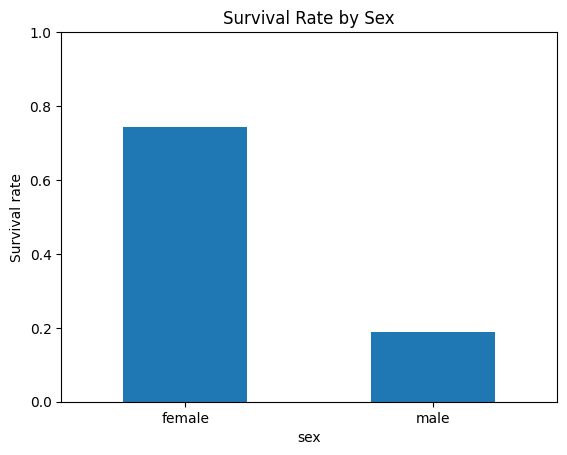

In [39]:
survival_by_sex.plot(
    kind="bar",
    rot=0,
    ylim=(0, 1),
    ylabel="Survival rate",
    title="Survival Rate by Sex"
)

plt.show()

❓ Why is the y-axis limited to the interval from 0 to 1?  
❓ Why is this graph more suitable for comparing survival between the groups than the previous countplot?

 ####  2. 🧩Individual Investigation:
 You will now apply the same workflow that we used for `sex` and `survived`.  
 Work individually.  Complete only the task assigned to you.  


 #### 🧩 Task A — Passenger Class and Survival:

 **Analytical Question:** How did observed survival rates differ across passenger classes?

Before writing code, identify:

- grouping variable:
- outcome variable:
- statistical types:
- relevant data-quality or feature-selection issue:
- numerical summaries:
- visualisation and justification:

In [42]:
# Task A: Calculate the number of passengers in each class
df["class"].value_counts

<bound method IndexOpsMixin.value_counts of 0       Third
1       First
2       Third
3       First
4       Third
        ...  
886    Second
887     First
888     Third
889     First
890     Third
Name: class, Length: 891, dtype: category
Categories (3, str): ['First', 'Second', 'Third']>

In [64]:
# Task A: Calculate the observed survival rate for each class
survival_by_class = df.groupby("class")["survived"].mean()
print(survival_by_class)

class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64


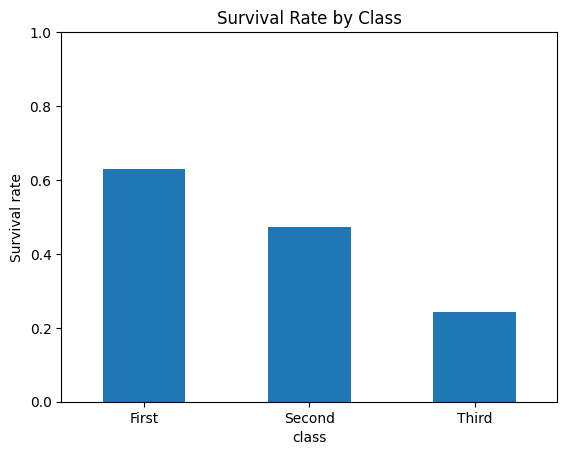

In [53]:
# Task A: create an appropriate visualisation
survival_by_class.plot(
    kind="bar",
    rot=0,
    ylim=(0, 1),
    ylabel="Survival rate",
    title="Survival Rate by Class"
)

plt.show()

Report the passenger classes with the highest and lowest observed survival rates: The First class 63%, the Third class 24%

#### 🧩Task B — Travelling Alone and Survival  

**Analytical Question:** How did observed survival rates differ between passengers travelling alone and passengers travelling with others?

Before writing code, identify:

- grouping variable:
- outcome variable:
- statistical types:
- relevant data-quality or feature-selection issue:
- numerical summaries:
- visualisation and justification:

In [50]:
# Task B: Calculate the number of passengers in each group
df["alone"].value_counts

<bound method IndexOpsMixin.value_counts of 0      False
1      False
2       True
3      False
4       True
       ...  
886     True
887     True
888    False
889     True
890     True
Name: alone, Length: 891, dtype: bool>

In [65]:
# Task B: Calculate the observed survival rate for each group
survival_by_one = df.groupby("alone")["survived"].mean()
print(survival_by_one)

alone
False    0.505650
True     0.303538
Name: survived, dtype: float64


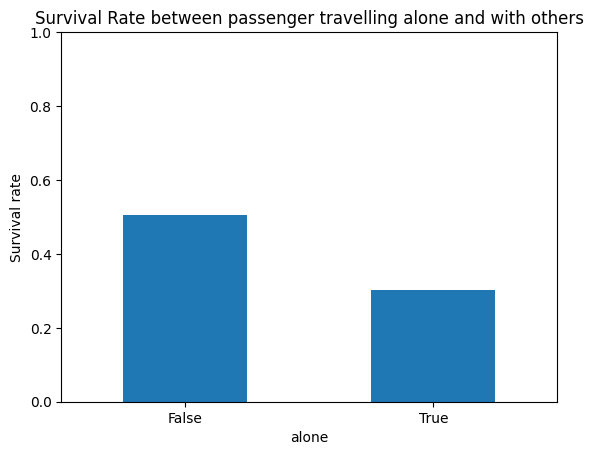

In [54]:
# Task B: Create an appropriate visualisation
survival_by_one.plot(
    kind="bar",
    rot=0,
    ylim=(0, 1),
    ylabel="Survival rate",
    title="Survival Rate between passenger travelling alone and with others"
)

plt.show()

Report which group had the higher observed survival rate and support your conclusion with numerical values: Passengers traveling not alone - 51%, traveling alone a survival rate - 30%

Suggest one additional variable that might help explain the observed difference: Passenger sex or age

#### 🧩 Task C — Embarkation Location and Survival

**Analytical Question:** How did passenger counts and observed survival rates differ across embarkation locations?

Before writing code, identify:

- grouping variable:
- outcome variable:
- statistical types:
- relevant missing or redundant information:
- numerical summaries:
- visualisation and justification:

In [55]:
# Task C: Check relevant missing values and calculate passenger counts
df["embark_town"].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [66]:
# Task C: Calculate the observed survival rate for each location
survival_by_location = df.groupby("embark_town")["survived"].mean()
print(survival_by_location)

embark_town
Cherbourg      0.553571
Queenstown     0.389610
Southampton    0.336957
Name: survived, dtype: float64


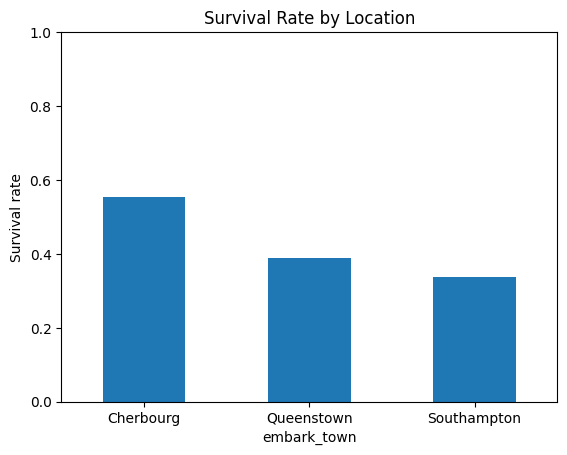

In [57]:
# Task C: Create an appropriate visualisation
survival_by_location.plot(
    kind="bar",
    rot=0,
    ylim=(0, 1),
    ylabel="Survival rate",
    title="Survival Rate by Location"
)

plt.show()

Report:

- the location with the most passengers: Southampton, 644
- the locations with the highest and lowest observed survival rates: Cherbourg ~55%, Southampton ~34%
- one limitation or possible alternative explanation for the differences: The difference is likely about who boarded the ship, not the city itself.

💡 .agg() allows us to calculate several summary statistics for each group in one operation.  

💡 An observed relationship does not necessarily imply causation. EDA helps us identify patterns and generate hypotheses, but it does not by itself explain why these patterns occur.

#### 3. Age and Fare

🧩 **Analytical Question:** Is passenger `age` linearly associated with `fare`?

❓ Identify statistical types of `age` and `fare` and an appropriate visualisation for examining their relationship.

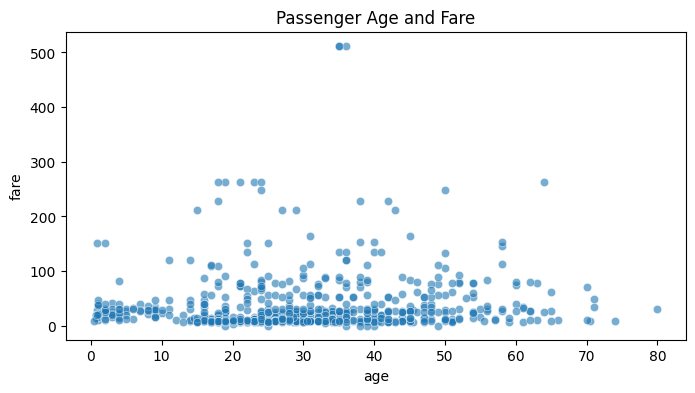

In [58]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="age", y="fare", alpha=0.6)

plt.title("Passenger Age and Fare")
plt.show()

❓ Does the scatter plot show a clear linear pattern?  
❓ Where do most observations appear to be concentrated?

### 4. Correlation  
The Pearson correlation coefficient \(r\) measures the strength and direction of a linear relationship between two numerical variables.

It ranges from −1 to 1:

- a positive value indicates a positive linear direction,
- a negative value indicates a negative linear direction,
- a value close to zero indicates a weak linear relationship.

In [59]:
df[["age", "fare"]].corr()

,age,fare
age,1.000000,0.096067
fare,0.096067,1.000000



❓ What does a correlation of approximately 0.10 suggest about the relationship between `age` and `fare`?  
❓ Does a weak correlation prove that age is useless for prediction model?

We can add a **regression line** to make the overall linear trend easier to see.

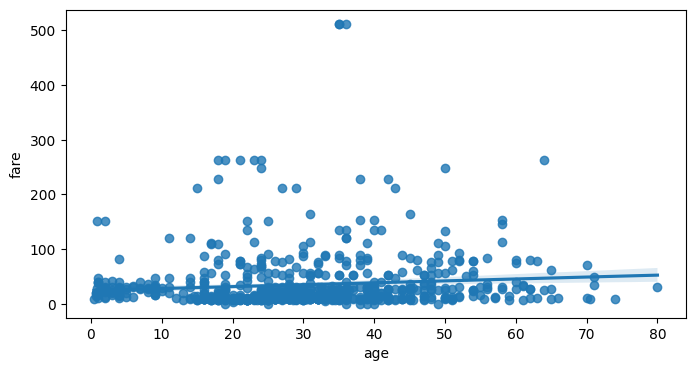

In [60]:
plt.figure(figsize=(8, 4))

sns.regplot(data=df, x="age", y="fare")

plt.show()

#### 5. Correlation Matrix  
A correlation matrix contains the pairwise Pearson correlations between selected numerical variables.

In [61]:
numeric_vars = df[["age", "fare", "sibsp", "parch"]]

numeric_vars.corr()

,age,fare,sibsp,parch
age,1.000000,0.096067,-0.308247,-0.189119
fare,0.096067,1.000000,0.159651,0.216225
sibsp,-0.308247,0.159651,1.000000,0.414838
parch,-0.189119,0.216225,0.414838,1.000000


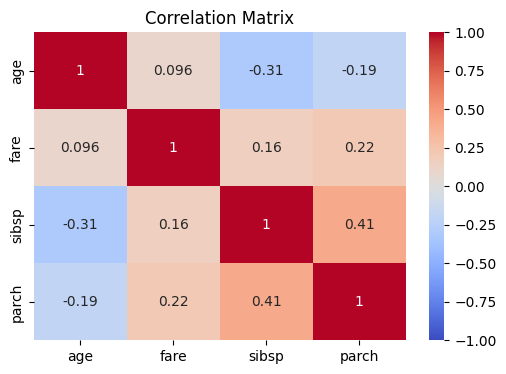

In [62]:
plt.figure(figsize=(6, 4))

sns.heatmap(numeric_vars.corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1)

plt.title("Correlation Matrix")
plt.show()

❓ Which pair of variables has the strongest positive/negative linear relationship? Is this relationship weak, moderate, or strong?  
❓ Should every column with a numerical Pandas dtype automatically be included in a Pearson correlation matrix? Why or why not?  
❓ Which numerical columns in the Titanic dataset would require special consideration?

**Key takeaways**  
💡Correlation does not imply causation. A correlation shows an association between variables, but it does not prove that one variable causes changes in the other.  

💡 Pearson correlation measures linear relationships. A value close to zero does not necessarily mean that no relationship exists; a nonlinear relationship may still be present.  

💡 Summary statistics do not describe the complete distribution. Different distributions may have similar summary statistics, so numerical summaries and visualisations should be interpreted together.

### Cheat Sheet

| Analytical question                                      | Variable types                    | Suitable visualisation |
| -------------------------------------------------------- | --------------------------------- | ---------------------- |
| What is the distribution of one numerical variable?      | One numerical variable            | Histogram, boxplot     |
| How frequent are the categories?                         | One categorical variable          | Count plot / bar chart |
| How does a numerical variable differ across groups?      | Numerical + categorical           | Grouped boxplot        |
| How does a rate or mean differ across groups?            | Numerical summary + categorical   | Bar chart              |
| Is there a relationship between two numerical variables? | Two numerical variables           | Scatter plot           |
| How does a value change over ordered time points?        | Time/ordered variable + numerical | Line plot              |


----

## 🎉 EDA: Completed ✓

####  <font color='#05c3de'> You survived the Titanic dataset. 🚢 </font>

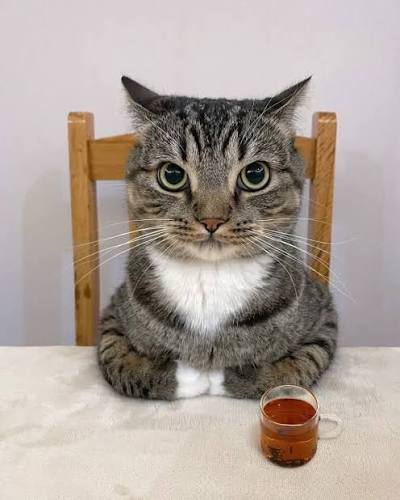

## From Exercise to Project: 
#### **Reporting Your EDA**

In your project, producing a table, statistic, or visualisation is only the beginning. Important EDA results and preprocessing decisions should be accompanied by a short Markdown explanation addressing:

- **Question:** What are you investigating?
- **Method:** Which variables, summaries, or visualisations did you use?
- **Finding:** What pattern, difference, or data-quality issue did you identify?
- **Evidence:** Which numerical values or visual features support the finding?
- **Interpretation:** What could the result mean in the context of the dataset?
- **Limitation:** What cannot be concluded from the result?
- **Decision or next step:** Does the finding suggest further analysis or preprocessing?

Not every minor output requires a detailed explanation. Focus on results and decisions that are important for understanding and preparing the data.